# 법률 문서 임베딩 학습 및 평가

한국어 Sentence-BERT 모델을 이용해 판례 검색 기준선을 만들고, 유사 문장 쌍으로 선택적 미세조정을 수행함. 현재 포함된 데이터는 기능 검증용 합성 데이터이므로 최종 실험에서는 출처가 명확한 실제 판례로 교체할 예정임.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sentence_transformers import InputExample, SentenceTransformer, losses

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data import documents_from_cases, load_cases

DATA_PATH = ROOT / 'data' / 'sample_cases.csv'
PAIR_PATH = ROOT / 'data' / 'training_pairs.csv'
MODEL_PATH = ROOT / 'models' / 'legal-sbert'
BASE_MODEL = 'jhgan/ko-sroberta-multitask'
print('device:', 'cuda' if torch.cuda.is_available() else 'cpu')

device: cpu


C:\Users\human-21\AppData\Local\Temp\ipykernel_15544\4156569026.py:9: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import InputExample, SentenceTransformer, losses


## 1. 데이터 확인 및 전처리

,case_name,category,issues
0,온라인 쇼핑몰 물품 하자 사건,소비자,제품 하자와 계약 해제 및 환불
1,중고차 성능 고지 위반 사건,소비자,중요 정보 미고지와 손해배상
2,임대차 보증금 반환 사건,부동산,임대차 종료와 보증금 반환
3,층간소음 손해배상 사건,부동산,생활 소음의 수인한도와 불법행위
4,부당해고 구제 사건,노동,징계 사유와 해고의 정당성


C:\Users\human-21\AppData\Local\Temp\ipykernel_15544\2458049988.py:6: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human-21\AppData\Local\Temp\ipykernel_15544\2458049988.py:6: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human-21\AppData\Local\Temp\ipykernel_15544\2458049988.py:6: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human-21\AppData\Local\Temp\ipykernel_15544\2458049988.py:6: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human-21\AppData\Local\Temp\ipykernel_15544\2458049988.py:6: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human-21\AppData\Local\Temp\ipykernel_15544\2458049988.py:6: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) mi

판례: 12건 / 학습 쌍: 12개


C:\Users\human-21\AppData\Local\Temp\ipykernel_15544\2458049988.py:6: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human-21\AppData\Local\Temp\ipykernel_15544\2458049988.py:6: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human-21\AppData\Local\Temp\ipykernel_15544\2458049988.py:6: UserWarning: Glyph 50556 (\N{HANGUL SYLLABLE YA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human-21\AppData\Local\Temp\ipykernel_15544\2458049988.py:6: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Python310\PROJECT2\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Python310\PROJECT2\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Gl

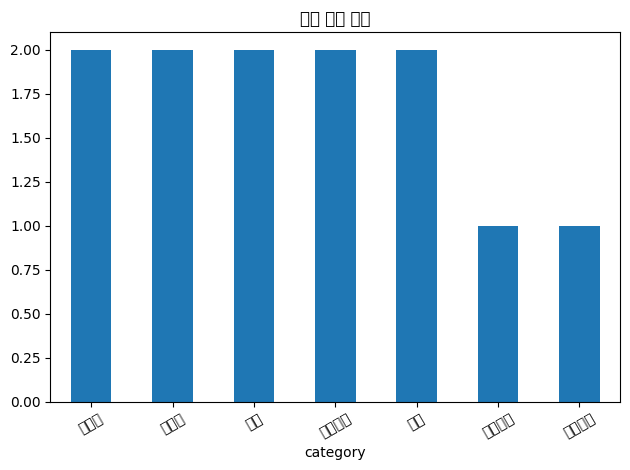

In [2]:
cases = load_cases(DATA_PATH)
pairs = pd.read_csv(PAIR_PATH)
display(cases[['case_name', 'category', 'issues']].head())
print(f'판례: {len(cases):,}건 / 학습 쌍: {len(pairs):,}개')
cases['category'].value_counts().plot.bar(title='사건 분야 분포', rot=30)
plt.tight_layout()
plt.show()

In [3]:
documents = documents_from_cases(cases)
print(documents[0][:500])

사건명: 온라인 쇼핑몰 물품 하자 사건
분야: 소비자
쟁점: 제품 하자와 계약 해제 및 환불
판결요지: 제품의 중대한 하자가 확인되고 판매자가 보수하지 않아 소비자의 계약 해제와 대금 반환 요구가 인정된 사례
본문: 소비자는 온라인 쇼핑몰에서 전자제품을 구입한 직후 반복적인 작동 불량을 발견하였다. 판매자는 사용상 과실을 주장했으나 감정 결과 제조상 결함이 확인되었다. 상당한 기간을 정해 보수를 요구했음에도 판매자가 조치하지 않아 계약 해제와 대금 반환을 청구하였다.


## 2. 기본 모델 검색 성능

각 판례의 `쟁점`을 질의로 사용하고, 동일 판례가 검색 결과 Top-K에 포함되는지 Recall@K로 평가함

In [4]:
model = SentenceTransformer(BASE_MODEL)
document_embeddings = model.encode(
    documents, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True
)
query_embeddings = model.encode(
    cases['issues'].tolist(), convert_to_numpy=True, normalize_embeddings=True
)

similarities = query_embeddings @ document_embeddings.T

def recall_at_k(score_matrix, k):
    top_indices = np.argsort(score_matrix, axis=1)[:, ::-1][:, :k]
    return np.mean([idx in top_indices[idx] for idx in range(len(top_indices))])

for k in [1, 3, 5]:
    print(f'Recall@{k}: {recall_at_k(similarities, k):.3f}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Recall@1: 1.000
Recall@3: 1.000
Recall@5: 1.000


## 3. 법률 유사 문장 쌍 미세조정

`RUN_TRAINING=True`로 변경하면 Multiple Negatives Ranking Loss로 모델을 학습함. 실제 실험에서는 학습·검증·테스트 데이터를 사건 단위로 분리하고 수천 개 이상의 판례 쌍을 사용.

In [5]:
RUN_TRAINING = False
EPOCHS = 1
BATCH_SIZE = 8

if RUN_TRAINING:
    train_examples = [
        InputExample(texts=[row.anchor, row.positive])
        for row in pairs.itertuples(index=False)
    ]
    train_loader = DataLoader(train_examples, shuffle=True, batch_size=BATCH_SIZE)
    train_loss = losses.MultipleNegativesRankingLoss(model)
    warmup_steps = max(1, int(len(train_loader) * EPOCHS * 0.1))

    model.fit(
        train_objectives=[(train_loader, train_loss)],
        epochs=EPOCHS,
        warmup_steps=warmup_steps,
        output_path=str(MODEL_PATH),
        show_progress_bar=True,
    )
    print('학습 모델 저장:', MODEL_PATH)
else:
    print('학습을 실행하려면 RUN_TRAINING을 True로 변경하세요.')

학습을 실행하려면 RUN_TRAINING을 True로 변경하세요.


## 4. 최종 모델 평가 및 검색 예시

In [6]:
final_model = SentenceTransformer(str(MODEL_PATH) if MODEL_PATH.exists() else BASE_MODEL)
final_document_embeddings = final_model.encode(
    documents, convert_to_numpy=True, normalize_embeddings=True
)

query = '인터넷에서 산 물건이 고장 났는데 판매자가 환불을 해주지 않는다'
query_vector = final_model.encode([query], convert_to_numpy=True, normalize_embeddings=True)[0]
scores = final_document_embeddings @ query_vector
top_indices = np.argsort(scores)[::-1][:3]

result = cases.iloc[top_indices][['case_name', 'category', 'issues']].copy()
result.insert(0, 'similarity', scores[top_indices])
display(result)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,similarity,case_name,category,issues
0,0.730870,온라인 쇼핑몰 물품 하자 사건,소비자,제품 하자와 계약 해제 및 환불
1,0.450878,중고차 성능 고지 위반 사건,소비자,중요 정보 미고지와 손해배상
11,0.315818,상표 유사성 및 혼동 사건,지식재산,상표의 유사성과 소비자 혼동 가능성


## 5. Streamlit용 전체 인덱스 저장

학습을 실행한 경우 아래 셀로 앱에서 사용할 임베딩과 판례 메타데이터를 갱신.

In [7]:
artifact_dir = ROOT / 'artifacts'
artifact_dir.mkdir(exist_ok=True)
np.save(artifact_dir / 'case_embeddings.npy', final_document_embeddings.astype('float32'))
cases.to_csv(artifact_dir / 'indexed_cases.csv', index=False, encoding='utf-8-sig')
print('인덱스 저장 완료:', artifact_dir)

인덱스 저장 완료: C:\Python310\PROJECT2\artifacts
